## Data Insights


This notebook loads `data/processed/publication_data.csv`, produced by `00_data_processing.ipynb`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import statsmodels.api as sm
from IPython.display import HTML
from scipy import stats

### Figure guidelines

In [ ]:
SERIF, SANS, BG = "Libre Baskerville", "Libre Franklin", "#F7F7F7"
RED, GREEN, GRAY = "#7A1E1A", "#236534", "#C9BFBA"

HOVER = dict(bgcolor="white", 
             bordercolor="rgba(0, 0, 0, 0.1)",
             font=dict(family=SANS, size=12, color="black"))

AXIS_DEFAULTS = dict(gridcolor="white", linecolor="white", ticks="", zerolinecolor="white",
                     zerolinewidth=2, automargin=True, title=dict(standoff=15))

SITE_TEMPLATE = dict(layout=dict(
    autotypenumbers="strict", hovermode="closest", font=dict(color="#2a3f5f"),
    hoverlabel=dict(align="left"), paper_bgcolor="white", plot_bgcolor="#E5ECF6",
    geo=dict(subunitcolor="white", showland=True, showlakes=True, lakecolor="white"),
    xaxis=AXIS_DEFAULTS, yaxis=AXIS_DEFAULTS,
))

def titled(fig, title, subtitle, legend=None, png=None, height=600, margin=None):
    """
    Add title/subtitle/legend back onto bare site figures, for display and figures/PNGs.
    
    """
    out = go.Figure(fig).update_layout(
        width=800, height=height, autosize=False, margin=margin,
        title=dict(
            x=0.5, font=dict(family=SERIF, size=18, color="black"),
            text=f"{title}<br><span style='font-family:{SANS};font-size:13px'>{subtitle}</span>",
        ),
    )
    if legend:
        out.add_annotation(
            x=0.5, y=1.02, xref="paper", yref="paper", xanchor="center", showarrow=False,
            font=dict(family=SANS, size=12, color="black"),
            text="&nbsp;&nbsp;&nbsp;&nbsp;".join(
                f"<span style='color:{color}'>●</span> {label}" for label, color in legend),
        )
    if png:
        out.write_image(f"../figures/{png}")
    return out

def write_chart_data(charts, path="../docs/chart-data.js"):
    """
    Produces script with plotly specs (../docs/js/chats-data.js).

    """
    blocks = []
    for chart_id, fig in charts.items():
        spec = json.loads(fig.to_json())
        spec["layout"]["template"] = SITE_TEMPLATE
        traces = ",\n  ".join(json.dumps(trace) for trace in spec["data"])
        blocks.append(f'{{"id": "{chart_id}",\n "data": [\n  {traces}\n ],\n'
                      f' "layout": {json.dumps(spec["layout"], indent=2)}}}')
    Path(path).write_text(
        "/* Generated by notebooks/01_data_analysis.ipynb.\n"
        "   Plotly specs for the three figures in index.html. */\n"
        "window.CHART_SPECS = [\n" + ",\n".join(blocks) + "\n];\n")
    print(f"wrote {path} ({Path(path).stat().st_size:,} bytes)")

def short_number(number):
    """
    Returns str: the short-form (K or M) of a long-form number (ex. 1000 becomes 1K).
     
    """

    for cutoff, suffix in ((1_000_000, "M"), (1_000, "K")):
        if abs(number) >= cutoff:
            scaled = number / cutoff
            return f"{int(scaled)}{suffix}" if scaled == int(scaled) else f"{round(scaled, 1)}{suffix}"
    return str(number)

def gradient_color(value, scale, low, high):
    """
    Get hex color for value in gradient
    """
    position = min(max((value - low) / (high - low), 0), 1) if high > low else 0.5
    index = min(int(position * (len(scale) - 1)), len(scale) - 2)
    fraction = position * (len(scale) - 1) - index
    start, end = (tuple(int(c[i:i + 2], 16) for i in (1, 3, 5)) for c in scale[index:index + 2])
    return "#%02x%02x%02x" % tuple(int(a + (b - a) * fraction) for a, b in zip(start, end))

In [3]:
merged_data = pd.read_csv("../data/processed/publication_data.csv")

wdi_cols = [c for c in merged_data.columns if c not in
            ['iso_alpha', 'Year', 'Publications', 'Country', 'data_source_flag']]
years_with_wdi = merged_data.loc[merged_data[wdi_cols].notna().any(axis=1), 'Year']

print(f"Country-year rows: {len(merged_data)}")
print(f"Distinct countries: {merged_data['Country'].nunique()}")
print(f"Years: {merged_data['Year'].min()}-{merged_data['Year'].max()}")
print(f"Years with WDI coverage: {years_with_wdi.min()}-{years_with_wdi.max()} ({years_with_wdi.nunique()} years)")

Country-year rows: 4020
Distinct countries: 201
Years: 2003-2022
Years with WDI coverage: 2003-2022 (20 years)


Window: 2016 - 2022. OSF published reproducibility crisis in 2015, and covid began 2019. This window attempts to capture psych post-reproducibility-crisis-awareness and the landscape pre-covid.

In [4]:
time_interval = merged_data[merged_data['Year'].between(2016, 2022)]

mean_cols = [
    'GDP_per_capita', 'GNI_per_capita_PPP', 'Population', 'Tertiary_enrollment_pct',
    'RnD_expenditure_pct', 'Researchers_per_million',
    'Education_expenditure_pct', 'Tertiary_education_expenditure_pct',
    'Urban_population_pct', 'Sci_tech_articles', 'Internet_users_pct',
]

country_summary = time_interval.groupby(['iso_alpha', 'Country'], as_index=False).agg(
    Publications=('Publications', 'sum'),
    SE_articles_total_subset=('SE_articles_total', lambda x: x.sum(min_count=1)),
    data_source_flag=('data_source_flag', 'first'),
    **{col: (col, 'mean') for col in mean_cols},
)

country_summary['psych_share'] = country_summary['Publications'] / country_summary['SE_articles_total_subset']
country_summary['log_publications'] = np.log1p(country_summary['Publications'])

print(f"Countries in 2016-2022 summary: {len(country_summary)}")
print(f"Total psychology publications (2016-2022): {country_summary['Publications'].sum():,.0f}")

Countries in 2016-2022 summary: 201
Total psychology publications (2016-2022): 388,583


### Global distribution, mapped

In [5]:
nonzero = country_summary['Publications'] > 0
q1, q2, q3 = country_summary.loc[nonzero, 'Publications'].quantile([0.25, 0.5, 0.75])
median = country_summary['Publications'].median()
plot_min = country_summary['Publications'].min()
plot_max = country_summary['Publications'].max()

print(f"zero contributions share: {(~nonzero).mean():.2%}")
print(f"min: {plot_min}, q1: {q1}, median (all): {median}, q2 (nonzero): {q2}, q3: {q3}, max: {plot_max}")

country_summary['quartile'] = 'Zero publications'
country_summary.loc[nonzero, 'quartile'] = pd.qcut(
    country_summary.loc[nonzero, 'Publications'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print(country_summary['quartile'].value_counts())

top_quartile = country_summary.sort_values('Publications', ascending=False)
bottom_quartile = country_summary[country_summary['Publications'] > 0].sort_values('Publications')

print(f"\nTop 5 contributors:\n{top_quartile.iloc[:5, :3]}")
print(f"\nBottom 5 contributors, non-zero:\n{bottom_quartile.iloc[:5, :3]}")

top_5 = top_quartile.iloc[:5].set_index('iso_alpha')['Country'].to_dict()

zero contributions share: 7.96%
min: 0.0, q1: 5.18, median (all): 26.0, q2 (nonzero): 39.54, q3: 559.67, max: 123318.51
quartile
Q1                   47
Q2                   46
Q3                   46
Q4                   46
Zero publications    16
Name: count, dtype: int64

Top 5 contributors:
    iso_alpha         Country  Publications
188       USA   United States     123318.51
62        GBR  United Kingdom      29975.06
45        DEU         Germany      24571.98
32        CHN           China      23294.01
29        CAN          Canada      18402.68

Bottom 5 contributors, non-zero:
    iso_alpha        Country  Publications
182       TUV         Tuvalu          0.05
39        COM        Comoros          0.20
67        GNB  Guinea-Bissau          0.29
110       MDA        Moldova          0.31
1         AGO         Angola          0.40


### US-specific

In [6]:
world_total = country_summary['Publications'].sum()
us = country_summary.loc[country_summary['Country'] == 'United States', 'Publications'].values[0]
print(f"world total: {world_total:,.0f}")
print(f"US share: {us / world_total:.1%}")

world_pop = country_summary['Population'].sum()
us_pop = country_summary.loc[country_summary['Country'] == 'United States', 'Population'].values[0]
print(f"US share of population: {us_pop / world_pop:.1%}\n")

non_us = country_summary[country_summary['Country'] != 'United States'].sort_values('Publications', ascending=False)

for rank, (_, row) in enumerate(non_us[:4].iterrows(), start=2):
    ratio = us / row['Publications']
    pop_share = row['Population'] / world_pop
    pub_share = row['Publications'] / world_total
    print(f"US is {ratio:.1f}x {row['Country']} (#{rank}), who has {pub_share:.1%} of world publications "
          f"and {pop_share:.1%} of world population")

top_5_total = us + top_quartile[1:5]['Publications'].sum()
print(f"\ntop 5 combined: {top_5_total / world_total:.1%} of world publications")

world total: 388,583
US share: 31.7%
US share of population: 4.2%

US is 4.1x United Kingdom (#2), who has 7.7% of world publications and 0.9% of world population
US is 5.0x Germany (#3), who has 6.3% of world publications and 1.1% of world population
US is 5.3x China (#4), who has 6.0% of world publications and 18.1% of world population
US is 6.7x Canada (#5), who has 4.7% of world publications and 0.5% of world population

top 5 combined: 56.5% of world publications


In [7]:
top_quartile_all_SE = country_summary.sort_values('SE_articles_total_subset', ascending=False)

print(f"\nTop 5 contributors, all SE subjects:\n{top_quartile_all_SE[:5].loc[:, ['Country','SE_articles_total_subset']]}")

top_5_SE_all_subjects = top_quartile_all_SE.iloc[:5].set_index('iso_alpha')['Country'].to_dict()


Top 5 contributors, all SE subjects:
            Country  SE_articles_total_subset
32            China                4393000.25
188   United States                3163979.20
79            India                1019653.21
45          Germany                 792711.31
62   United Kingdom                 730490.14


In [8]:
world_total = country_summary['SE_articles_total_subset'].sum()
cn = country_summary.loc[country_summary['Country'] == 'China', 'SE_articles_total_subset'].values[0]
print(f"world total: {world_total:,.0f}")

non_cn = country_summary[country_summary['Country'] != 'China'].sort_values('SE_articles_total_subset', ascending=False)

for rank, (_, row) in enumerate(non_cn[:4].iterrows(), start=2):
    ratio = cn / row['SE_articles_total_subset']
    pop_share = row['Population'] / world_pop
    pub_share = row['SE_articles_total_subset'] / world_total
    print(f"China is {ratio:.1f}x {row['Country']} (#{rank}), who has {pub_share:.1%} of all world publications "
          f"and {pop_share:.1%} of world population")

top_5_total = cn + top_quartile_all_SE[1:5]['SE_articles_total_subset'].sum()
print(f"\ntop 5 combined: {top_5_total / world_total:.1%} of all world publications")

world total: 19,767,197
China is 1.4x United States (#2), who has 16.0% of all world publications and 4.2% of world population
China is 4.3x India (#3), who has 5.2% of all world publications and 17.9% of world population
China is 5.5x Germany (#4), who has 4.0% of all world publications and 1.1% of world population
China is 6.0x United Kingdom (#5), who has 3.7% of all world publications and 0.9% of world population

top 5 combined: 51.1% of all world publications


In [9]:
red_scale = ["#F4E8D8", "#D6A89A", "#A3473F", "#7A1E1A"]
low, high = country_summary['log_publications'].min(), country_summary['log_publications'].max()

country_summary['hover_color'] = country_summary['log_publications'].map(
    lambda x: gradient_color(x, red_scale, low, high))
country_summary['pub_share_world'] = (country_summary['Publications'] / world_total).round(6)
country_summary['pop_share_world'] = (country_summary['Population'] / world_pop).round(6)

pub_ticks = [0, 10, 100, 1000, 10000, 100000]

map_fig = go.Figure(go.Choropleth(
    locations=country_summary['iso_alpha'].tolist(),
    locationmode='ISO-3',
    z=country_summary['log_publications'].round(4).tolist(),
    colorscale=red_scale,
    customdata=country_summary[['Country', 'Publications', 'hover_color',
                                'pub_share_world', 'pop_share_world']].values.tolist(),
    hovertemplate="<b>%{customdata[0]} </b>"
                  "<span style='color:%{customdata[2]};vertical-align:middle'>■</span><br>"
                  "%{customdata[1]:,} publications<br>"
                  "%{customdata[3]:.1%} of world publications<br>"
                  "%{customdata[4]:.1%} of world population<extra></extra>",
    colorbar=dict(
        orientation='h', x=0.5, y=-0.12, xanchor='center', yanchor='middle',
        len=0.4, thickness=15, outlinewidth=0, ticks="",
        tickvals=[round(float(np.log1p(v)), 4) for v in pub_ticks],
        ticktext=[short_number(v) for v in pub_ticks],
        tickfont=dict(family=SANS, size=9, color="black"),
        title=dict(text="<b>Publications (Log Scale)</b>", side="top",
                   font=dict(family=SANS, size=12, color="black")),
    ),
))

map_fig.update_geos(showcountries=True, countrycolor="lightgray", countrywidth=0.5,
                    landcolor="#DAD7D7", showframe=False, bgcolor=BG, fitbounds="locations")

map_fig.update_layout(
    autosize=True, paper_bgcolor=BG, margin=dict(t=0, b=80, l=10, r=10, autoexpand=False),
    hoverlabel=HOVER,
)

titled(map_fig,
       "The US produced the largest share of global psychology publications",
       "Scopus Psychology Publications by Country (2016-2022), Fractional Contributions",
       png="main_map.png", height=500, margin=dict(t=100, b=80, l=10, r=10))

### Change over time

In [10]:
panel_cy = merged_data.groupby(['iso_alpha', 'Year'], as_index=False)['Publications'].sum()

world_by_year = panel_cy.groupby('Year')['Publications'].sum()
panel_cy = panel_cy.merge(world_by_year.rename('world_total'), left_on='Year', right_index=True)
panel_cy['share_of_world'] = panel_cy['Publications'] / panel_cy['world_total']

trend_countries = {"USA":"United States", "GBR":"United Kingdom", "CAN":"Canada", "DEU":"Germany", "CHN":"China"}
trend_colors = {"United States": RED, 
                "China": GREEN, 
                "United Kingdom": "#8C9BA5",
                "Canada": "#B5A08C", 
                "Germany": "#6B5744"}
legend_order = ["United States", "China", "United Kingdom", "Canada", "Germany"]

trend_fig = go.Figure()

for iso, name in trend_countries.items():
    sub = panel_cy[panel_cy['iso_alpha'] == iso].sort_values('Year')
    trend_fig.add_trace(go.Scatter(
        x=sub['Year'].tolist(), y=(sub['share_of_world'] * 100).round(4).tolist(),
        mode="lines+markers", name=name, showlegend=False,
        line=dict(color=trend_colors[name], width=3),
        marker=dict(size=6, color=trend_colors[name]),
        hovertemplate=f"<b>{name}</b><br>Year: %{{x}}<br>Share: %{{y:.2f}}%<extra></extra>",
    ))

trend_fig.update_xaxes(title="<b>Year</b>", showgrid=False, zeroline=False, automargin=False,
                       tickfont=dict(family=SANS, size=12))
trend_fig.update_yaxes(title="<b>Share of world psychology publications (%)</b>", showgrid=True,
                       gridcolor="#E5E5E5", zeroline=False, automargin=False,
                       tickfont=dict(family=SANS, size=12))

trend_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(family=SANS, size=12, color="black"),
    hoverlabel=HOVER,
    margin=dict(t=20, b=70, l=90, r=20),
)

titled(trend_fig,
       "US psychology share fell as China overtook the UK, Canada, and Germany",
       "Five largest contributors by total output (2003-2022), as a share of world publications",
       legend=[(name, trend_colors[name]) for name in legend_order],
       png="global_share_overtime.png", margin=dict(t=120, b=70, l=90, r=40))


### Do psychology publications scale with the size of a country's overall science output?

In [11]:
rho = country_summary[['psych_share', 'SE_articles_total_subset']].corr(method='spearman').loc['psych_share', 'SE_articles_total_subset']
print(f"Spearman rho = {rho:.3f}")

Spearman rho = 0.308


In [12]:
top = (
    country_summary
    .dropna(subset=['SE_articles_total_subset', 'psych_share'])
    .nlargest(15, 'SE_articles_total_subset')
    .copy()
)

top['rank_volume'] = top['SE_articles_total_subset'].rank(ascending=False)
top['rank_share'] = top['psych_share'].rank(ascending=False)
top['shift'] = top['rank_volume'] - top['rank_share']

rank_fig = go.Figure()

for _, r in top.iterrows():
    moved = abs(r['shift']) > 3
    color = RED if r['shift'] < -3 else GREEN if r['shift'] > 3 else GRAY

    rank_fig.add_trace(go.Scatter(
        x=[0, 1], y=[r['rank_volume'], r['rank_share']],
        mode="lines+markers", showlegend=False, opacity=1.0 if moved else 0.45,
        line=dict(color=color, width=3 if moved else 1.5),
        marker=dict(size=9, color=color, line=dict(width=0.6, color="white")),
        hovertemplate=(
            f"<b>{r['Country']}</b><br>"
            f"#{int(r['rank_volume'])} in total science output<br>"
            f"#{int(r['rank_share'])} by psychology's share of national science output"
            "<extra></extra>"
        ),
    ))

    for x, y, anchor in ((-0.08, r['rank_volume'], "right"), (1.08, r['rank_share'], "left")):
        rank_fig.add_annotation(x=x, y=y, text=r['Country'], xanchor=anchor, showarrow=False,
                                font=dict(family=SANS, size=12, color=color))

rank_fig.update_xaxes(
    range=[-0.35, 1.35], showgrid=False, zeroline=False, tickvals=[0, 1], tickangle=0,
    ticktext=["<b>Total S&E<br>publication output</b>", "<b>Psychology, % of<br>national S&E output</b>"],
    tickfont=dict(family=SANS, size=14),
)
rank_fig.update_yaxes(autorange="reversed", showgrid=False, zeroline=False, showticklabels=False)

rank_fig.update_layout(
    autosize=True, paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(family=SANS, size=12, color="black"),
    hoverlabel=HOVER,
    margin=dict(t=15, b=50, l=80, r=80, autoexpand=False),
)

titled(rank_fig,
       "A large science sector doesn't necessarily devote a larger share to psychology",
       "Top 15 countries by total science output (2016-2022), reranked by psychology's share of national science output",
       legend=[("Fell >3 ranks", RED), ("Rose >3 ranks", GREEN), ("Shift of 3 or fewer", GRAY)],
       png="rank_shift.png", height=750, margin=dict(t=130, b=60, l=110, r=110))

### Predictors

In [13]:
base = country_summary.dropna(subset=['SE_articles_total_subset']).copy()
print(base[['Publications', 'SE_articles_total_subset', 'psych_share']].describe().round(4).to_string())

       Publications  SE_articles_total_subset  psych_share
count      201.0000              2.010000e+02     201.0000
mean      1933.2467              9.834426e+04       0.0139
std       9494.8390              4.043803e+05       0.0121
min          0.0000              7.700000e-01       0.0000
25%          3.1400              2.948800e+02       0.0046
50%         26.0000              2.793680e+03       0.0108
75%        401.7100              4.126694e+04       0.0197
max     123318.5100              4.393000e+06       0.0550


In [14]:
# Funnel diagnostic

base['granularity'] = 1 / base['SE_articles_total_subset']
base['den_decile'] = pd.qcut(base['SE_articles_total_subset'], 20, labels=False)

spread = base.groupby('den_decile').agg(
    n=('psych_share', 'size'),
    den_max=('SE_articles_total_subset', 'max'),
    granularity=('granularity', 'median'),
    share_sd=('psych_share', 'std'),
    share_iqr=('psych_share', lambda x: x.quantile(.75) - x.quantile(.25)),
).round(5)

spread['granularity_ratio'] = spread['granularity'] / spread['share_sd']

print(spread.to_string())

             n     den_max  granularity  share_sd  share_iqr  granularity_ratio
den_decile                                                                     
0           11       28.16      0.06770   0.00593    0.00000          11.416526
1           10       70.17      0.02302   0.01784    0.02100           1.290359
2           10      118.62      0.01028   0.00794    0.00978           1.294710
3           10      204.68      0.00678   0.01773    0.02579           0.382403
4           10      294.88      0.00401   0.00587    0.00279           0.683135
5           10      523.94      0.00236   0.01340    0.01063           0.176119
6           10      987.81      0.00151   0.00968    0.00909           0.155992
7           10     1318.18      0.00086   0.00681    0.00947           0.126285
8           10     1767.25      0.00059   0.00735    0.00998           0.080272
9           10     2793.68      0.00050   0.00758    0.00575           0.065963
10          10     4250.19      0.00030 

In [15]:
THRESHOLD = 500
d = base[(base['SE_articles_total_subset'] >= THRESHOLD) &
         (base['Publications'] > 0)].dropna(subset=['GDP_per_capita']).copy()
print(f"n = {len(d)}")

n = 142


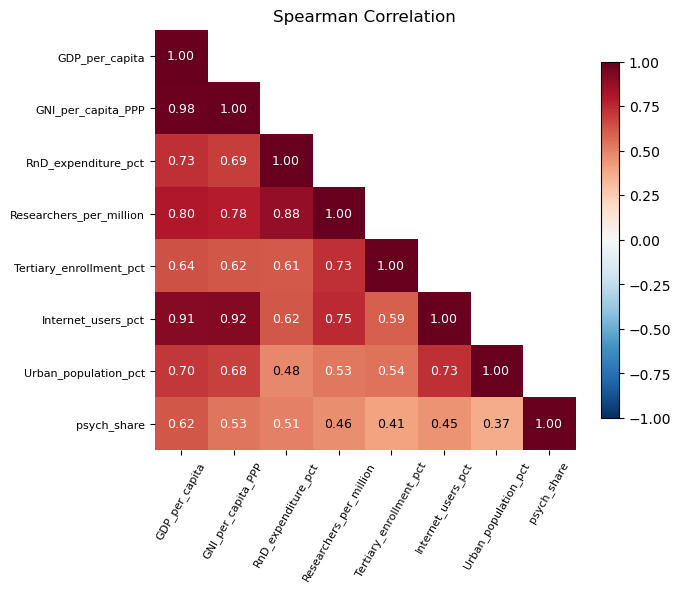

In [16]:
preds = ['GDP_per_capita', 'GNI_per_capita_PPP', 'RnD_expenditure_pct',
         'Researchers_per_million', 'Tertiary_enrollment_pct',
         'Internet_users_pct', 'Urban_population_pct']

sub = d[preds + ['psych_share']].dropna()
spear = sub.corr(method='spearman')
spear_masked = spear.where(np.tril(np.ones(spear.shape)).astype(bool))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(spear_masked, cmap='RdBu_r', vmin=-1, vmax=1, origin='upper')

ax.set_xticks(range(len(spear)))
ax.set_xticklabels(spear.columns, rotation=60, fontsize=8)
ax.set_yticks(range(len(spear)))
ax.set_yticklabels(spear.columns, fontsize=8)
ax.set_title('Spearman Correlation')

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(len(spear)):
    for j in range(len(spear)):
        val = spear_masked.iloc[i, j]
        if pd.notna(val):
            val = float(val) # type: ignore
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(val) > 0.5 else "black")

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

### OLS

scale only : R^2 = 0.870
adding log GDPpc: R^2 = 0.905
                            OLS Regression Results                            
Dep. Variable:               log_pubs   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     662.9
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           8.25e-72
Time:                        20:50:50   Log-Likelihood:                -167.31
No. Observations:                 142   AIC:                             340.6
Df Residuals:                     139   BIC:                             349.5
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

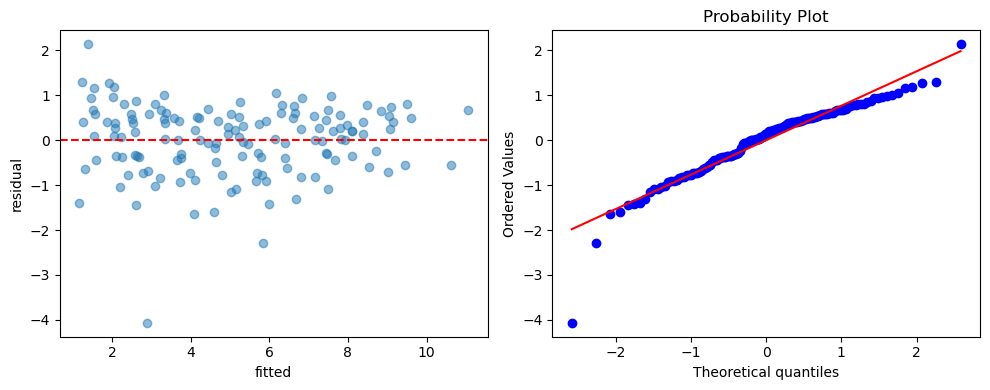

In [17]:
# OLS

m = d.dropna(subset=['GDP_per_capita']).copy()
m['log_pubs'] = np.log(m['Publications'])
m['log_total'] = np.log(m['SE_articles_total_subset'])
m['log_gdp'] = np.log(m['GDP_per_capita'])

fit_scale = sm.OLS(m['log_pubs'], sm.add_constant(m[['log_total']])).fit(cov_type='HC3')
fit_nested = sm.OLS(m['log_pubs'], sm.add_constant(m[['log_total', 'log_gdp']])).fit(cov_type='HC3')

print(f"scale only : R^2 = {fit_scale.rsquared:.3f}")
print(f"adding log GDPpc: R^2 = {fit_nested.rsquared:.3f}")
print(fit_nested.summary())

top5 = m.nlargest(5, 'Publications').index
rows = [('full sample', fit_nested.params['log_gdp'], len(m))]
for idx in top5:
    sub = m.drop(idx)
    f = sm.OLS(sub['log_pubs'], sm.add_constant(sub[['log_total', 'log_gdp']])).fit(cov_type='HC3')
    rows.append((f"drop {m.loc[idx, 'Country']}", f.params['log_gdp'], len(sub)))
print(pd.DataFrame(rows, columns=['sample', 'log_gdp coef', 'n']).round(3).to_string(index=False))

resid = fit_nested.resid
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(fit_nested.fittedvalues, resid, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('fitted'); axes[0].set_ylabel('residual')

stats.probplot(resid, dist="norm", plot=axes[1])
plt.tight_layout()


Residuals aren't normal. Small number of countries has much lower output than above OLS model predicts:
- Negative cluster
- QQ deviates at left tail

### PPML, no fixed effects

$$\log(E[\text{Publications}_i]) = \beta_0 + \beta_1 \cdot \log(\text{GDP\_per\_capita\_PPP}_i) + 1 \cdot \log(\text{SE\_articles\_total}_i)$$

In [ ]:
# Compute without denominator cutoff

panel = merged_data.dropna(subset=['GDP_per_capita_PPP', 'SE_articles_total']).copy()
panel = panel[panel['SE_articles_total'] > 0].copy()

panel['log_gdp'] = np.log(panel['GDP_per_capita_PPP'])
panel['offset'] = np.log(panel['SE_articles_total'])

print(f"Panel: {len(panel)} country-years, {panel['iso_alpha'].nunique()} countries, "
      f"{panel['Year'].min()}-{panel['Year'].max()}")
print(f"Zero-publication country-years retained: {(panel['Publications'] == 0).sum()} "
      f"({(panel['Publications'] == 0).mean():.1%}) ")

balance = panel.groupby('Year').size()
print(f"Country-years per year: min {balance.min()} ({balance.idxmin()}), "
      f"max {balance.max()} ({balance.idxmax()})")

zero_by_country = panel.groupby('iso_alpha')['Publications'].apply(lambda x: (x == 0).mean())
print(zero_by_country.sort_values(ascending=False).head(20))

Panel: 3761 country-years, 193 countries, 2003-2022
Zero-publication country-years retained: 999 (26.6%) 
Country-years per year: min 185 (2005), max 190 (2009)
iso_alpha
PLW    1.000000
TLS    1.000000
STP    1.000000
DJI    1.000000
MHL    1.000000
KIR    1.000000
FSM    1.000000
GNQ    1.000000
NRU    1.000000
VUT    0.950000
TKM    0.950000
SLB    0.950000
COM    0.950000
LCA    0.950000
MDV    0.950000
TUV    0.941176
AND    0.900000
WSM    0.900000
ATG    0.900000
ERI    0.888889
Name: Publications, dtype: float64


In [ ]:
year_dummies = pd.get_dummies(panel['Year'], prefix='yr', drop_first=True, dtype=float)

# Check offset restriction is near 1

Xp_unrestricted = sm.add_constant(pd.concat(
    [panel[['log_gdp', 'offset']].rename(columns={'offset': 'log_total'}), year_dummies], axis=1
))
ppml_unrestricted = sm.GLM(panel['Publications'], Xp_unrestricted, family=sm.families.Poisson()).fit(
    cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

b = ppml_unrestricted.params['log_total']
se = ppml_unrestricted.bse['log_total']
print(f"unrestricted log_total coef: {b:.3f} (se {se:.3f})")
print(f"test coef == 1: z = {(b - 1) / se:.2f}")


#### Sensitivity to year fixed effects

In [ ]:
# Without year dummies
X_no_dummies = sm.add_constant(panel[['log_gdp']])
ppml_no_dummies = sm.GLM(
    panel['Publications'], X_no_dummies, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})
print("\nWithout year dummies:")
print(f"  log_gdp coef: {ppml_no_dummies.params['log_gdp']:.3f} (se {ppml_no_dummies.bse['log_gdp']:.3f})")

# With year dummies
X_with_dummies = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies], axis=1))
ppml_with_dummies = sm.GLM(
    panel['Publications'], X_with_dummies, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

print("\nWith year dummies:")
print(f"  log_gdp coef: {ppml_with_dummies.params['log_gdp']:.3f} (se {ppml_with_dummies.bse['log_gdp']:.3f})")


unrestricted log_total coef: 1.017 (se 0.037)
test coef == 1: z = 0.45

Without year dummies:
  log_gdp coef: 1.164 (se 0.146)

With year dummies:
  log_gdp coef: 1.219 (se 0.154)


### PPML with country fixed effects: within-country vs. between-country variation

In [ ]:
country_dummies = pd.get_dummies(panel['iso_alpha'], prefix='c', drop_first=True, dtype=float)

# no country FE (year FE only)
Xp = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies], axis=1))
ppml_no_fe = sm.GLM(
    panel['Publications'], Xp, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

# with country FE
Xp_fe = sm.add_constant(pd.concat([panel[['log_gdp']], year_dummies, country_dummies], axis=1))
ppml_fe = sm.GLM(
    panel['Publications'], Xp_fe, family=sm.families.Poisson(), offset=panel['offset']
).fit(cov_type='cluster', cov_kwds={'groups': panel['iso_alpha']})

print(f"log_gdp, no country FE : {ppml_no_fe.params['log_gdp']:.3f} (se {ppml_no_fe.bse['log_gdp']:.3f})")
print(f"log_gdp, with country FE: {ppml_fe.params['log_gdp']:.3f} (se {ppml_fe.bse['log_gdp']:.3f})")

pearson_chi2 = ppml_fe.pearson_chi2
dof = ppml_fe.df_resid
print(f"Pearson chi2/df, with country FE: {pearson_chi2/dof:.2f}")

log_gdp, no country FE : 1.219 (se 0.154)
log_gdp, with country FE: 1.075 (se 0.339)
Pearson chi2/df, with country FE: 5.60


In [ ]:
panel['log_gdp_x_trend'] = panel['log_gdp'] * (panel['Year'] - 2011)

Xp_interact = sm.add_constant(pd.concat(
    [panel[['log_gdp', 'log_gdp_x_trend']], year_dummies, country_dummies], axis=1
))

ppml_interact = sm.GLM(
    panel['Publications'],
    Xp_interact, family=sm.families.Poisson(),
    offset=panel['offset']
).fit(
    cov_type='cluster',
    cov_kwds={'groups': panel['iso_alpha']}
)

b_main = ppml_interact.params['log_gdp']
b_trend = ppml_interact.params['log_gdp_x_trend']
se_trend = ppml_interact.bse['log_gdp_x_trend']

print(f"log_gdp (at 2011): {b_main:.3f} (se {ppml_interact.bse['log_gdp']:.3f})")
print(f"log_gdp x year trend: {b_trend:.3f} (se {se_trend:.3f})")
print(f"z-test on the trend: {b_trend / se_trend:.2f}")

for year in [2003, 2011, 2016, 2022]:
    effect = b_main + b_trend * (year - 2011)
    pct = (2**effect - 1) * 100
    print(f"implied log_gdp effect in {year}: {effect:.3f} ({pct:.0f}% more psych output per GDP doubling)")

log_gdp (at 2011): 0.819 (se 0.219)
log_gdp x year trend: -0.028 (se 0.007)
z-test on the trend: -3.94
implied log_gdp effect in 2003: 1.045 (106% more psych output per GDP doubling)
implied log_gdp effect in 2011: 0.819 (76% more psych output per GDP doubling)
implied log_gdp effect in 2016: 0.677 (60% more psych output per GDP doubling)
implied log_gdp effect in 2022: 0.508 (42% more psych output per GDP doubling)


In [ ]:
pearson_chi2_int = ppml_interact.pearson_chi2
dof_int = ppml_interact.df_resid
print(f"Pearson chi2/df: {pearson_chi2_int/dof_int:.2f}")

Pearson chi2/df: 5.92


Generate `docs/chart-data.js` for `docs/index.html`.

In [23]:
write_chart_data({"c1": map_fig, "c2": rank_fig, "c3": trend_fig})

wrote ../docs/chart-data.js (35,006 bytes)
